# Sample Scatter Plots

Translated from QMCPy's sample_scatter_plots.ipynb

Generates point sets from different discrete distributions and
true measures, printing summary statistics. For actual scatter plots,
run this data through your preferred Julia plotting library (Plots.jl,
Makie.jl, etc.).

This script outputs CSV-like data you can paste into a plotter.

In [1]:
using QMC
import QMC: Uniform
using Statistics
using Printf

# Plots.jl is an optional visualisation dep; guard all scatter/plot cells
# so this notebook runs cleanly in headless CI environments.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots

n = 128

128

IID Samples

In [2]:
println("="^60)
println("IID Uniform Samples (n=$n, d=2)")
println("="^60)

dd_iid = IIDStdUniform(2; seed=7)
x_iid = gen_samples(dd_iid, n)
@printf("  Range: x₁ ∈ [%.4f, %.4f], x₂ ∈ [%.4f, %.4f]\n",
        minimum(x_iid[:,1]), maximum(x_iid[:,1]),
        minimum(x_iid[:,2]), maximum(x_iid[:,2]))
@printf("  Mean:  (%.4f, %.4f)\n", mean(x_iid[:,1]), mean(x_iid[:,2]))
println()

IID Uniform Samples (n=128, d=2)
  Range: x₁ ∈ [0.0000, 0.9875], x₂ ∈ [0.0031, 0.9869]
  Mean:  (0.4644, 0.4993)



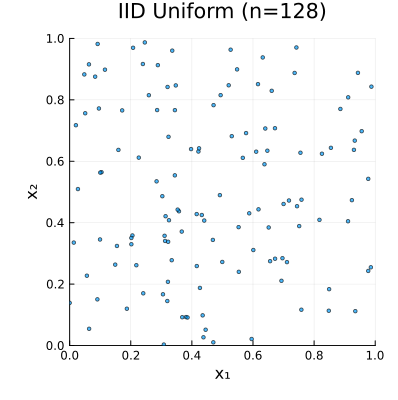

In [3]:
if HAVE_PLOTS
    # Scatter plot of IID samples
    scatter(x_iid[:, 1], x_iid[:, 2],
        xlabel="x₁", ylabel="x₂",
        title="IID Uniform (n=$n)",
        label=nothing, markersize=2, alpha=0.7,
        aspect_ratio=:equal, xlims=(0,1), ylims=(0,1),
        size=(400, 400))
end

Low-Discrepancy Samples

In [4]:
println("="^60)
println("Low-Discrepancy Samples (n=$n, d=2)")
println("="^60)

for (name, dd) in [
    ("Shifted Lattice",     Lattice(2; randomize=true, seed=7)),
    ("Scrambled Sobol'",    DigitalNetB2(2; randomize="LMS_DS", seed=7)),
    ("Generalized Halton",  Halton(2; randomize=true, seed=7)),
]
    local x
    x = gen_samples(dd, n)
    @printf("  %-20s: mean = (%.4f, %.4f), range x₁ = [%.4f, %.4f]\n",
            name, mean(x[:,1]), mean(x[:,2]),
            minimum(x[:,1]), maximum(x[:,1]))
end
println()

Low-Discrepancy Samples (n=128, d=2)
  Shifted Lattice     : mean = (0.5029, 0.5027), range x₁ = [0.0068, 0.9990]
  Scrambled Sobol'    : mean = (0.5006, 0.4992), range x₁ = [0.0045, 0.9967]
  Generalized Halton  : mean = (0.4967, 0.4992), range x₁ = [0.0006, 0.9928]



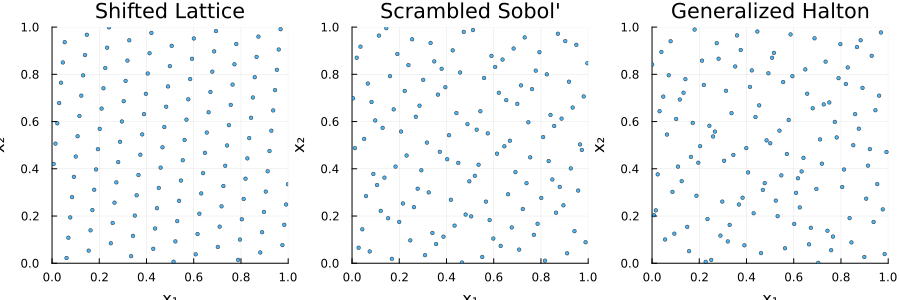

In [5]:
if HAVE_PLOTS
    # Scatter plots comparing low-discrepancy sequences
    ld_plots = []
    for (name, dd) in [
        ("Shifted Lattice",     Lattice(2; randomize=true, seed=7)),
        ("Scrambled Sobol'",    DigitalNetB2(2; randomize="LMS_DS", seed=7)),
        ("Generalized Halton",  Halton(2; randomize=true, seed=7)),
    ]
        local x = gen_samples(dd, n)
        p = scatter(x[:, 1], x[:, 2],
            xlabel="x₁", ylabel="x₂",
            title=name,
            label=nothing, markersize=2, alpha=0.7,
            aspect_ratio=:equal, xlims=(0,1), ylims=(0,1))
        push!(ld_plots, p)
    end
    plot(ld_plots..., layout=(1, 3), size=(900, 300))
end

Transformed Samples: Uniform → Gaussian

In [6]:
println("="^60)
println("Transform to Gaussian Measure")
println("="^60)

for (name, dd) in [
    ("IID",     IIDStdUniform(2; seed=7)),
    ("Lattice", Lattice(2; randomize=true, seed=7)),
    ("Sobol'",  DigitalNetB2(2; seed=7)),
    ("Halton",  Halton(2; randomize=true, seed=7)),
]
    local tm, x, xt
    tm = Gaussian(dd; mean=0.0, covariance=1.0)
    x = gen_samples(dd, n)
    xt = transform(tm, x)
    @printf("  %-8s → N(0,1): mean = (%+.3f, %+.3f), std = (%.3f, %.3f)\n",
            name, mean(xt[:,1]), mean(xt[:,2]), std(xt[:,1]), std(xt[:,2]))
end
println()

Transform to Gaussian Measure
  IID      → N(0,1): mean = (+0.120, -0.000), std = (0.981, 0.932)
  Lattice  → N(0,1): mean = (-0.019, +0.017), std = (1.005, 1.004)
  Sobol'   → N(0,1): mean = (-0.004, -0.005), std = (0.999, 0.999)
  Halton   → N(0,1): mean = (+0.022, -0.013), std = (1.009, 0.995)



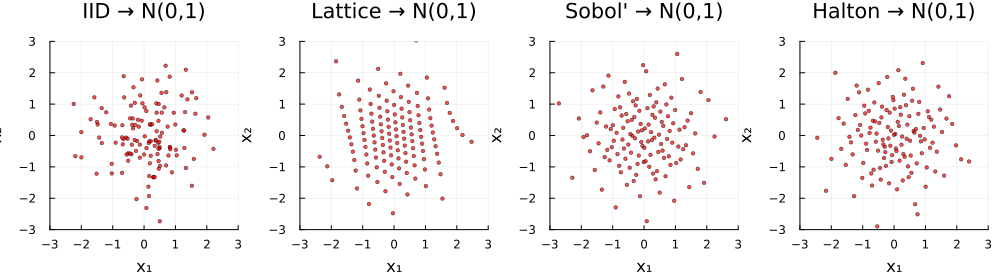

In [7]:
if HAVE_PLOTS
    # Scatter plots: Uniform → Gaussian transform
    gauss_plots = []
    for (name, dd) in [
        ("IID",     IIDStdUniform(2; seed=7)),
        ("Lattice", Lattice(2; randomize=true, seed=7)),
        ("Sobol'",  DigitalNetB2(2; seed=7)),
        ("Halton",  Halton(2; randomize=true, seed=7)),
    ]
        local tm = Gaussian(dd; mean=0.0, covariance=1.0)
        local x = gen_samples(dd, n)
        local xt = transform(tm, x)
        p = scatter(xt[:, 1], xt[:, 2],
            xlabel="x₁", ylabel="x₂",
            title="$name → N(0,1)",
            label=nothing, markersize=2, alpha=0.7, color=:red,
            aspect_ratio=:equal, xlims=(-3,3), ylims=(-3,3))
        push!(gauss_plots, p)
    end
    plot(gauss_plots..., layout=(1, 4), size=(1000, 280))
end

Transformed Samples: Uniform → BrownianMotion

In [8]:
println("="^60)
println("Transform to Brownian Motion")
println("="^60)

for (name, dd) in [
    ("IID",     IIDStdUniform(2; seed=7)),
    ("Lattice", Lattice(2; randomize=true, seed=7)),
    ("Sobol'",  DigitalNetB2(2; seed=7)),
    ("Halton",  Halton(2; randomize=true, seed=7)),
]
    local tm, x, xt
    tm = BrownianMotion(dd)
    x = gen_samples(dd, n)
    xt = transform(tm, x)
    @printf("  %-8s → BM: mean = (%+.3f, %+.3f), var = (%.3f, %.3f)\n",
            name, mean(xt[:,1]), mean(xt[:,2]), var(xt[:,1]), var(xt[:,2]))
end
println("  (BM: Var[W(t₁)] = t₁ = 0.5, Var[W(t₂)] = t₂ = 1.0)")
println()

Transform to Brownian Motion
  IID      → BM: mean = (-0.072, -0.116), var = (0.462, 0.963)
  Lattice  → BM: mean = (+0.005, +0.022), var = (0.517, 0.998)
  Sobol'   → BM: mean = (+0.004, +0.002), var = (0.502, 0.995)
  Halton   → BM: mean = (-0.008, -0.025), var = (0.515, 1.006)
  (BM: Var[W(t₁)] = t₁ = 0.5, Var[W(t₂)] = t₂ = 1.0)



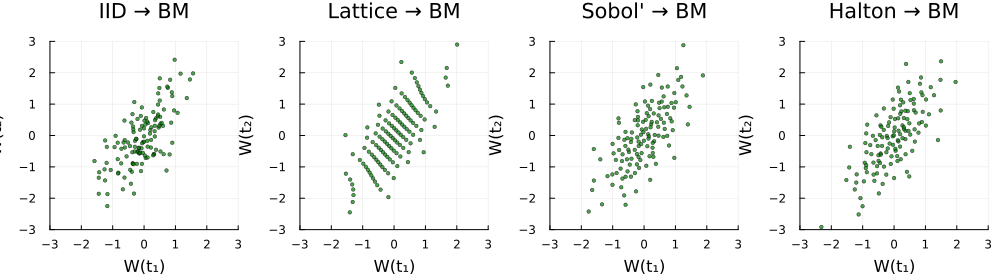

In [9]:
if HAVE_PLOTS
    # Scatter plots: Uniform → Brownian Motion
    bm_plots = []
    for (name, dd) in [
        ("IID",     IIDStdUniform(2; seed=7)),
        ("Lattice", Lattice(2; randomize=true, seed=7)),
        ("Sobol'",  DigitalNetB2(2; seed=7)),
        ("Halton",  Halton(2; randomize=true, seed=7)),
    ]
        local tm = BrownianMotion(dd)
        local x = gen_samples(dd, n)
        local xt = transform(tm, x)
        p = scatter(xt[:, 1], xt[:, 2],
            xlabel="W(t₁)", ylabel="W(t₂)",
            title="$name → BM",
            label=nothing, markersize=2, alpha=0.7, color=:green,
            aspect_ratio=:equal, xlims=(-3,3), ylims=(-3,3))
        push!(bm_plots, p)
    end
    plot(bm_plots..., layout=(1, 4), size=(1000, 280))
end

Shifted & Stretched: Custom Uniform and Gaussian

In [10]:
println("="^60)
println("Shifted & Stretched Measures (Sobol')")
println("="^60)

dd = DigitalNetB2(2; randomize="LMS_DS", seed=7)
x = gen_samples(dd, n)

Shifted & Stretched Measures (Sobol')


128×2 Matrix{Float64}:
 0.848245   0.354704
 0.348245   0.854704
 0.598245   0.104704
 0.0982454  0.604704
 0.973245   0.479704
 0.473245   0.979704
 0.723245   0.229704
 0.223245   0.729704
 0.160745   0.792204
 0.660745   0.292204
 0.410745   0.542204
 0.910745   0.042204
 0.0357454  0.917204
 ⋮          
 0.840433   0.628142
 0.340433   0.128142
 0.590433   0.878142
 0.0904329  0.378142
 0.0279329  0.0656415
 0.527933   0.565642
 0.277933   0.315642
 0.777933   0.815642
 0.152933   0.190642
 0.652933   0.690642
 0.402933   0.440642
 0.902933   0.940642

Custom Uniform[2,4] × Uniform[6,8]

In [11]:
tm_u = Uniform(dd; lower_bound=[2.0, 6.0], upper_bound=[4.0, 8.0])
xu = transform(tm_u, x)
@printf("  Uniform([2,4]×[6,8]): mean = (%.2f, %.2f)\n", mean(xu[:,1]), mean(xu[:,2]))

  Uniform([2,4]×[6,8]): mean = (3.00, 7.00)


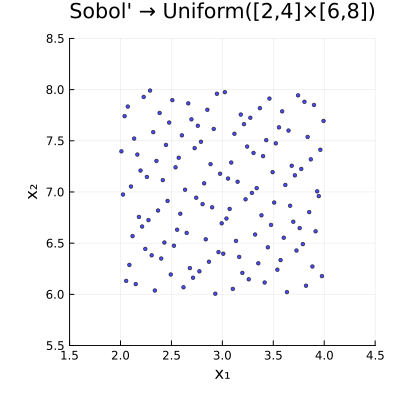

In [12]:
if HAVE_PLOTS
    # Scatter plot: Custom Uniform[2,4] × Uniform[6,8]
    scatter(xu[:, 1], xu[:, 2],
        xlabel="x₁", ylabel="x₂",
        title="Sobol' → Uniform([2,4]×[6,8])",
        label=nothing, markersize=2, alpha=0.7, color=:blue,
        aspect_ratio=:equal, xlims=(1.5, 4.5), ylims=(5.5, 8.5),
        size=(400, 400))
end

Custom Gaussian with covariance

In [13]:
Σ = [9.0 5.0; 5.0 9.0]
tm_g = Gaussian(dd; mean=[3.0, 7.0], covariance=Σ)
xg = transform(tm_g, gen_samples(DigitalNetB2(2; seed=7), n))
@printf("  Gaussian(μ=[3,7], Σ): mean = (%.2f, %.2f)\n", mean(xg[:,1]), mean(xg[:,2]))
println()

  Gaussian(μ=[3,7], Σ): mean = (3.02, 7.00)



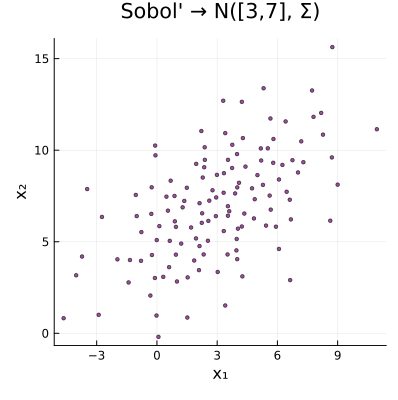

In [14]:
if HAVE_PLOTS
    # Scatter plot: Custom Gaussian with covariance
    scatter(xg[:, 1], xg[:, 2],
        xlabel="x₁", ylabel="x₂",
        title="Sobol' → N([3,7], Σ)",
        label=nothing, markersize=2, alpha=0.7, color=:purple,
        size=(400, 400))
end

Keister Function Evaluation

In [15]:
println("="^60)
println("Keister Function Integration (d=2)")
println("="^60)

dd = IIDStdUniform(2; seed=7)
tm = Gaussian(dd; covariance=0.5)
f = Keister(tm)
sc = CubMCCLT(f; abs_tol=0.3)
result = integrate(sc)
exact = keister_exact(2)
@printf("  Solution: %.4f (exact = %.4f)\n", result.solution, exact)
@printf("  Samples:  %d\n", result.data[:n])

println()
println("="^60)
println("Sample scatter plots demo completed!")
println("  (Use Plots.jl or Makie.jl to visualize the point sets)")

Keister Function Integration (d=2)
  Solution: 1.7910 (exact = 1.8082)
  Samples:  2048

Sample scatter plots demo completed!
  (Use Plots.jl or Makie.jl to visualize the point sets)
